# Fine-tuning DNABERT for COVID Sequence Classification

## 1. Introduction

In this notebook, we will learn how to fine-tune a pre-trained language model for DNA sequences ([DNABERT-2](https://arxiv.org/abs/2306.15006)) to classify COVID-19 variants.

### What is Fine-tuning?
Fine-tuning is a transfer learning technique where we take a model pre-trained on a general task and adapt it to a specific task. It's like taking a student who already knows how to read (pre-training) and teaching them to understand specific scientific texts (fine-tuning).

### What is Hugging Face?
[Hugging Face](https://huggingface.co/) is like the 'GitHub' of Machine Learning models. It's a platform that provides:
- Thousands of pre-trained models ready to use
- Tools for training and sharing models
- An active community of developers and researchers

### Project Overview
In this project, we will:
1. Learn how to prepare genomic data for deep learning
2. Use DNABERT, a state-of-the-art DNA language model
3. Fine-tune the model for COVID variant classification
4. Make predictions on new DNA sequences

Technical implementation will include:
- Data preprocessing with k-mer tokenization
- Attention mechanism for sequence understanding
- Cross-entropy loss for multi-class classification
- Learning rate scheduling with warmup
- Gradient accumulation for memory efficiency
- Model evaluation with precision, recall, and F1 metrics

This knowledge can be applied to many other DNA sequence classification tasks, such as:
- Promoter identification
- Binding site prediction
- Genetic variant classification
- Enhancer recognition
- DNA-protein interaction prediction




## 2. Environment Setup and Data Preparation

### 2.1 Required Libraries
First, we'll install and import the necessary libraries for our analysis. These tools will help us handle DNA sequences and work with machine learning models efficiently.


In [1]:
!pip install transformers datasets torch numpy polars scikit-learn seaborn

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import polars as pl
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Check if we have GPU acceleration available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Available device: {device}')

Available device: cuda


# 3. Load dataset Genome Understanding Evaluation (GUE)
Original GUE dataset can be [downloaded](https://huggingface.co/datasets/leannmlindsey/GUE/tree/main/GUE/virus_covid) at Hugging Face

In [3]:
df_train = pl.read_csv("train.csv")
df_test = pl.read_csv("test.csv")
df_val = pl.read_csv("dev.csv")
df_train.head()

FileNotFoundError: No such file or directory (os error 2): train.csv

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style using a valid matplotlib style
plt.style.use('ggplot')  # or you can use 'classic', 'bmh', 'ggplot', etc.

# Create figure and subplots
plt.figure(figsize=(15, 6))

# Plot distribution for each dataset
plt.subplot(1, 3, 1)
sns.countplot(data=df_train, x='label')
plt.title('Class Distribution - Training Set')
plt.xlabel('Class')
plt.ylabel('Number of Samples')

plt.subplot(1, 3, 2)
sns.countplot(data=df_val, x='label')
plt.title('Class Distribution - Validation Set')
plt.xlabel('Class')
plt.ylabel('Number of Samples')

plt.subplot(1, 3, 3)
sns.countplot(data=df_test, x='label')
plt.title('Class Distribution - Test Set')
plt.xlabel('Class')
plt.ylabel('Number of Samples')

# Adjust layout
plt.tight_layout()
plt.show()


# 3.1 Prepare tokenizer and model DNABERT
Download tokenizer and model from Hugging Face

### Why DNABERT?
DNABERT is a specialized model for DNA sequences, pre-trained on large amounts of genomic data. It's like having an expert who already understands the 'language' of DNA, and now we're going to specialize it in identifying COVID-19 variants.

Technical advantages:
- Pre-trained on 6-mer tokenization strategy
- Understands complex DNA motifs and patterns
- Bidirectional context understanding through attention
- Handles variable-length sequences
- Supports both sequence classification and token classification tasks

### Model Architecture
DNABERT is based on the BERT architecture with specific modifications for DNA:
- 12-layer Transformer encoder
- 768 hidden dimensions
- 12 attention heads
- ~110M parameters
- Specialized DNA vocabulary
- Maximum sequence length of 512 tokens

In [ ]:
# Load model and tokenizer
# Specify the model name
model_name = "zhihan1996/DNA_bert_6"
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
# Load the model
model = AutoModelForSequenceClassification.from_pretrained(model_name,
                                                         num_labels=len(df_train['label'].unique()))
model = model.to(device)

## 3.2 Data Preprocessing: Creating Datasets and Tokenization

Before training, we need to convert our raw DNA sequence data into a format suitable for deep learning. This involves two main steps:

1. **Creating Datasets:**  
    We organize our data into training, validation, and test sets, each containing DNA sequences and their corresponding labels.

2. **Tokenization:**  
    We use a *tokenizer* to split each DNA sequence into smaller overlapping fragments called *k-mers* (subsequences of length k). The tokenizer translates these k-mers into numerical tokens that the model can understand, similar to how words are converted to numbers in natural language processing.

Tokenization is essential because deep learning models require numerical input, and k-mer tokenization helps the model capture important patterns in DNA sequences.

In [ ]:
def polars_to_hf_dataset(df):
    """
    Convert a Polars DataFrame with columns 'sequence' and 'label'
    into a Hugging Face Dataset.

    Parameters:
    df (polars.DataFrame): Input dataframe with 'sequence' and 'label' columns.

    Returns:
    datasets.Dataset: Hugging Face Dataset with the same data.
    """
    df_dict = {
        'sequence': df['sequence'].to_list(),
        'label': df['label'].to_list()
    }
    return Dataset.from_dict(df_dict)

# Convert Polars DataFrames to Hugging Face Datasets
training_dataset = polars_to_hf_dataset(df_train)
validation_dataset = polars_to_hf_dataset(df_val)
test_dataset = polars_to_hf_dataset(df_test)

def preprocess_function(data):
    """
    Tokenize DNA sequences using the loaded tokenizer.

    Parameters:
    data (dict): Dictionary with a 'sequence' key containing DNA sequences.

    Returns:
    dict: Tokenized sequences with attention masks and input IDs.
    """
    return tokenizer(
        data['sequence'],
        truncation=True,
        padding='max_length',
        max_length=512  # Adjust max_length according to your sequences
    )
# Tokenize the training dataset
tokenized_dataset_train = training_dataset.map(preprocess_function, batched=True)
tokenized_dataset_val = validation_dataset.map(preprocess_function, batched=True)
tokenized_dataset_test = test_dataset.map(preprocess_function, batched=True)

## 4. Training Configuration and Model Fine-tuning

### 4.1 Setting Training Parameters
We'll configure the training process with parameters optimized for genomic sequence analysis:

In [ ]:

training_args = TrainingArguments(
    # Basic Training Parameters
    output_dir='./dnabert_covid',          # Directory where model checkpoints will be saved during training
    num_train_epochs=1,                    # The model will process the entire dataset 3 times
    per_device_train_batch_size=8,         # Number of sequences processed simultaneously during training
    per_device_eval_batch_size=8,          # Number of sequences processed simultaneously during evaluation
    # Optimization Parameters
    warmup_steps=500,                      # The first 500 steps will gradually increase the learning rate to avoid early training instability
    weight_decay=0.01,                     # Regularization parameter that prevents overfitting by penalizing large weights
    # Logging and Evaluation
    logging_dir='./logs',                  # Directory where training logs will be stored
    logging_steps=10,                      # Training metrics will be logged every 10 steps
    eval_strategy="epoch",           # Model performance will be evaluated at the end of each epoch
    save_strategy="epoch",                 # Model checkpoints will be saved at the end of each epoch
    # Model Selection
    load_best_model_at_end=True,          # After training, loads the model checkpoint that performed best
    metric_for_best_model="f1",            # Uses F1 score to determine the best mode
    report_to="none"
)


### Understanding the F1 Score

The F1 score is a crucial metric in machine learning, especially for classification tasks. Here's why it's important:

#### What is the F1 Score?
- It's the harmonic mean of precision and recall
- Formula: F1 = 2 * (Precision * Recall) / (Precision + Recall)
- Ranges from 0 (worst) to 1 (best)

#### Components:
1. **Precision**: Of all the sequences we predicted as a specific variant, how many were actually that variant?
   - Precision = True Positives / (True Positives + False Positives)

2. **Recall**: Of all the actual sequences of a specific variant, how many did we correctly identify?
   - Recall = True Positives / (True Positives + False Negatives)

#### Why Use F1 Score?
- Balances precision and recall
- Particularly useful for imbalanced datasets (when some variants are more common than others)
- Provides a single score that captures both false positives and false negatives

### Example:
If our model predicts COVID variants:
- High precision: Rarely misidentifies one variant as another
- High recall: Rarely misses instances of any variant
- High F1 score: Performs well on both metrics

This balanced approach is crucial for reliable variant classification, where both false positives and false negatives can have significant implications.


### 4.2 Define metrics of evaluation

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

### 4.2 Preparing the Training Pipeline
We'll split our data into training and validation sets, similar to dividing samples into experimental and control groups:


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset_train,    # Using pre-split training dataset
    eval_dataset=tokenized_dataset_val,       # Using pre-split validation dataset
    compute_metrics=compute_metrics
)


### 4.3 Model Training
Now we'll initiate the training process. This is where DNABERT learns to identify specific COVID-19 variants from DNA sequences:


In [ ]:
# Begin training
print("Starting model training...")
training_results = trainer.train()

# Display training metrics
print("\nTraining completed. Final metrics:")
print(training_results.metrics)

# Save the trained model
output_dir = "dnabert2_finetuned_covid"
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)
print(f"Model saved at: {output_dir}")

Initial results of Fine tuning

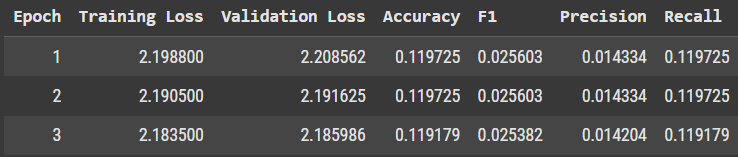

## 7. Load trained model

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

"""# Define the path where the model was saved
model_path = "dnabert2_finetuned_covid"


# Load tokenizer and model
#tokenizer = AutoTokenizer.from_pretrained(model_path)
#model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
"""
# Create trainer instance with loaded model
trainer = Trainer(
    model=model
)

print("Model and tokenizer loaded successfully!")

Model and tokenizer loaded successfully!


## 6. Using your trained model

In [ ]:
def predict_tokenized(tokenized_sequence, trainer):
    """
    Make a prediction for a single DNA sequence.

    Args:
        sequence (str): DNA sequence to classify
        trainer (Trainer): Trained model trainerr

    Returns:
        dict: Prediction results including class and probabilities
    """
    # Convert to PyTorch tensors and move to device
    inputs = {
        k: torch.tensor(v).unsqueeze(0).to(trainer.model.device)
        for k, v in tokenized_sequence.items()
        if k in ['input_ids', 'attention_mask']
    }

    # Make prediction
    with torch.no_grad():
        outputs = trainer.model(**inputs)
        probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
        predicted_class = torch.argmax(probabilities, dim=-1).item()
        confidence = probabilities[0][predicted_class].item()

    return {
        "predicted_class": predicted_class,
        "confidence": confidence
    }

# Example usage with tokenized dataset
print("Making predictions on example sequences from test set:")
for i in range(3):  # Let's try with first 3 sequences
    # Get a tokenized sequence from the test dataset
    tokenized_sequence = tokenized_dataset_test[i]

    # Make prediction
    result = predict_tokenized(tokenized_sequence, trainer)

    print(f"\nSequence {i+1}:")
    print(f"True Label: {tokenized_sequence['label']}")
    print(f"Predicted Class: {result['predicted_class']}")
    print(f"Confidence: {result['confidence']:.4f}")

Making predictions on example sequences from test set:

Sequence 1:
True Label: 2
Predicted Class: 2
Confidence: 0.1139

Sequence 2:
True Label: 0
Predicted Class: 7
Confidence: 0.1138

Sequence 3:
True Label: 8
Predicted Class: 3
Confidence: 0.1251
